# Class 25: Numerical Motion Under Central Forces
### Computational Methods for Classical Mechanics with Python

This notebook focuses on **how to integrate motion under central forces directly in time**.


## What is a central force?

A central force always points along the line joining the particle to the origin.

Examples include:
- gravity from a fixed mass,
- electrostatic attraction or repulsion,
- an isotropic spring force centered at the origin.

In two dimensions, the particle position is

$$
\mathbf{r}(t) = (x(t), y(t)).
$$

The distance from the origin is

$$
r = \sqrt{x^2 + y^2}.
$$

If the force magnitude depends only on $r$, then the acceleration is directed radially.


## Inverse-square force written in components

For a fixed central gravitational field, the acceleration is

$$
\mathbf{a} = -\frac{\mu}{r^3}\mathbf{r},
$$

where $\mu$ is a constant.

Since

$$
\mathbf{r} = (x,y),
$$

the component equations are

$$
\ddot{x} = -\frac{\mu x}{(x^2+y^2)^{3/2}},
$$

$$
\ddot{y} = -\frac{\mu y}{(x^2+y^2)^{3/2}}.
$$

To solve numerically, define velocities

$$
v_x = \dot{x}, \qquad v_y = \dot{y}.
$$

Then the system becomes

$$
\dot{x} = v_x,
\qquad
\dot{y} = v_y,
$$

$$
\dot{v}_x = -\frac{\mu x}{(x^2+y^2)^{3/2}},
\qquad
\dot{v}_y = -\frac{\mu y}{(x^2+y^2)^{3/2}}.
$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML


## Midpoint method for 2D motion

We now write a reusable midpoint solver for motion in the plane.

The state of the particle is:
- position: `(x, y)`
- velocity: `(vx, vy)`

At each time step:
1. compute the acceleration from the current position,
2. estimate midpoint values,
3. use the midpoint slope to update the solution.


In [2]:
def midpoint_2d_xy(acceleration, t0, tf, x0, y0, vx0, vy0, h):
    # Create the time array
    t = np.arange(t0, tf+h, h)

    # Allocate arrays to store the solution
    x = np.zeros_like(t)
    y = np.zeros_like(t)
    vx = np.zeros_like(t)
    vy = np.zeros_like(t)
    # Set the initial conditions
    x[0] = x0
    y[0] = y0
    vx[0] = vx0
    vy[0] = vy0

    # Step forward in time
    for n in range(len(t)-1):
        # Acceleration at the current step
        ax_n, ay_n = acceleration(x[n],y[n],vx[n],vy[n])

        # Midpoint estimates for position
        x_mid = x[n] + 0.5*h*vx[n]
        y_mid = y[n] + 0.5*h*vy[n]

        # Midpoint estimates for velocity
        vx_mid = vx[n] + 0.5*h*ax_n
        vy_mid = vy[n] + 0.5*h*ay_n


        # Acceleration at the midpoint
        ax_mid, ay_mid = acceleration(x_mid,y_mid,vx_mid,vy_mid)

        # Final midpoint update
        x[n+1] = x[n] + h*vx_mid
        y[n+1] = y[n] + h*vy_mid
        vx[n+1] = vx[n] + h*ax_mid
        vy[n+1] = vy[n] + h*ay_mid


    return t, x, y, vx, vy


## Animation helper

The next function animates a single particle moving in the plane.


In [3]:
def animate_xy_motion(x, y, title="2D Motion", interval=20, show_trail=True):
    fig, ax = plt.subplots(figsize=(6, 6))
    margin = 1.1 * max(np.max(np.abs(x)), np.max(np.abs(y)))
    if margin == 0:
        margin = 1.0

    ax.set_xlim(-margin, margin)
    ax.set_ylim(-margin, margin)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    ax.grid(True)
    ax.set_aspect("equal")
    ax.plot(0, 0, "o", markersize=10)

    point, = ax.plot([], [], "o")
    trail, = ax.plot([], [], "-", alpha=0.7)

    def init():
        point.set_data([], [])
        trail.set_data([], [])
        return point, trail

    def update(frame):
        point.set_data([x[frame]], [y[frame]])
        if show_trail:
            trail.set_data(x[:frame+1], y[:frame+1])
        return point, trail

    ani = FuncAnimation(fig, update, frames=len(x), init_func=init, interval=interval, blit=True)
    plt.close(fig)
    return ani


## Acceleration function for the inverse-square force

For the inverse-square law,

$$
\ddot{x} = -\frac{\mu x}{(x^2+y^2)^{3/2}},
\qquad
\ddot{y} = -\frac{\mu y}{(x^2+y^2)^{3/2}}.
$$


In [4]:
mu = 1.0

def inverse_square_accel(x, y, vx, vy):
    r = np.sqrt(x**2+y**2)
    ax = - mu*x/r**3
    ay = - mu*y/r**3

    return ax, ay


## Elliptical orbit

With suitable initial conditions, the inverse-square force produces a bound elliptical orbit.


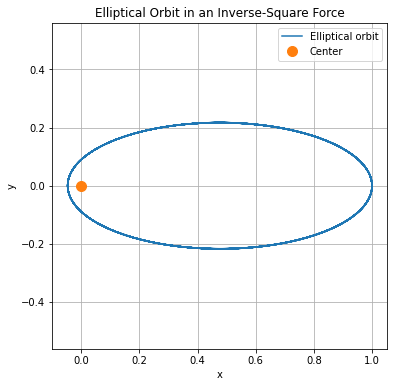

In [11]:
t_ell, x_ell, y_ell, vx_ell, vy_ell = midpoint_2d_xy(
    inverse_square_accel,
    t0=0.0, tf=30.0,
    x0=1.0, y0=0.0,
    vx0=0.0, vy0=0.3,
    h=0.0001
)

plt.figure(figsize=(6, 6))
plt.plot(x_ell, y_ell, label="Elliptical orbit")
plt.plot(0, 0, "o", markersize=10, label="Center")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Elliptical Orbit in an Inverse-Square Force")
plt.grid(True)
plt.legend()
plt.axis("equal")
plt.show()


In [ ]:
ani_ell = animate_xy_motion(x_ell, y_ell, title="Elliptical Orbit")
HTML(ani_ell.to_jshtml())

## Parabolic-like escape trajectory

If the initial speed is near the escape speed, the orbit becomes parabolic (or nearly parabolic numerically).


In [ ]:
v_escape = np.sqrt(2 * mu / 1.0)

t_par, x_par, y_par, vx_par, vy_par = midpoint_2d_xy(
    inverse_square_accel,
    t0=0.0, tf=8.0,
    x0=1.0, y0=0.0,
    vx0=0.0, vy0=v_escape,
    h=0.001
)

plt.figure(figsize=(6, 6))
plt.plot(x_par, y_par, label="Near-parabolic orbit")
plt.plot(0, 0, "o", markersize=10, label="Center")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Near-Parabolic Escape Trajectory")
plt.grid(True)
plt.legend()
plt.axis("equal")
plt.show()


In [ ]:
ani_par = animate_xy_motion(x_par, y_par, title="Near-Parabolic Trajectory")
HTML(ani_par.to_jshtml())


## Hyperbolic trajectory

If the initial speed is greater than the escape speed, the particle follows an unbound hyperbolic trajectory.


In [ ]:
t_hyp, x_hyp, y_hyp, vx_hyp, vy_hyp = midpoint_2d_xy(
    inverse_square_accel,
    t0=0.0, tf=8.0,
    x0=1.0, y0=0.0,
    vx0=0.0, vy0=1.6,
    h=0.001
)

plt.figure(figsize=(6, 6))
plt.plot(x_hyp, y_hyp, label="Hyperbolic orbit")
plt.plot(0, 0, "o", markersize=10, label="Center")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Hyperbolic Trajectory")
plt.grid(True)
plt.legend()
plt.axis("equal")
plt.show()


In [ ]:
ani_hyp = animate_xy_motion(x_hyp, y_hyp, title="Hyperbolic Trajectory")
HTML(ani_hyp.to_jshtml())


## Rosette orbits from non-$1/r^2$ forces

Now let us change the force law.

For a general power law,

$$
F(r) = -\frac{k}{r^n},
$$

the component acceleration becomes

$$
\ddot{x} = -k\frac{x}{r^{n+1}},
\qquad
\ddot{y} = -k\frac{y}{r^{n+1}}.
$$

When $n \neq 2$, the orbit is usually not a closed ellipse.  
Instead, it often precesses and creates a rosette pattern.


In [ ]:
def power_law_accel_factory(k=1.0, n=2.0):
    def accel(x, y, vx, vy):
        
        return ax, ay
    return accel


In [ ]:
accel_n2 = power_law_accel_factory(k=1.0, n=2.0)
accel_nnot2 = power_law_accel_factory(k=1.0, n=1.8)

common_kwargs = dict(t0=0.0, tf=80.0, x0=1.0, y0=0.0, vx0=0.0, vy0=0.8, h=0.01)

_, x_n2, y_n2, _, _ = midpoint_2d_xy(accel_n2, **common_kwargs)
_, x_nnot2, y_nnot2, _, _ = midpoint_2d_xy(accel_nnot2, **common_kwargs)

plt.figure(figsize=(7, 7))
plt.plot(x_n2, y_n2, label=r"$n=2.0$")
plt.plot(x_nnot2, y_nnot2, label=r"$n=1.8$")
plt.plot(0, 0, "o", markersize=10, label="Center")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Closed Orbit vs Rosette Orbits")
plt.grid(True)
plt.legend()
plt.axis("equal")
plt.show()


In [ ]:
ani_ros = animate_xy_motion(x_n22, y_n22, title="Rosette Orbit for a Non-1/r^2 Force")
HTML(ani_ros.to_jshtml())


## A simple two-body problem

Now both masses move under mutual gravity:

$$
\ddot{\mathbf r}_1=Gm_2\frac{\mathbf r_2-\mathbf r_1}{|\mathbf r_2-\mathbf r_1|^3},\qquad
\ddot{\mathbf r}_2=Gm_1\frac{\mathbf r_1-\mathbf r_2}{|\mathbf r_1-\mathbf r_2|^3}.
$$


In [ ]:
def midpoint_two_body(m1, m2, x1_0, y1_0, vx1_0, vy1_0, x2_0, y2_0, vx2_0, vy2_0, tf, h, G=1.0):
    # Create the time array


    # Allocate arrays to store the solution


    # Set the initial conditions


    # define a function to compute the accelerations on both bodies
    def accelerations(x1v, y1v, x2v, y2v):

        return ax1, ay1, ax2, ay2

    # Step forward in time
    for n in range(len(t) - 1):
        # Acceleration at the current step

        # Midpoint estimates for position and velocity


        # Acceleration at the midpoint


        # Final midpoint update


    return t, x1, y1, vx1, vy1, x2, y2, vx2, vy2


In [ ]:
t_2b, x1, y1, vx1, vy1, x2, y2, vx2, vy2 = midpoint_two_body(
    m1=1.0, m2=0.2,
    x1_0=-0.2, y1_0=0.0, vx1_0=0.0, vy1_0=-0.15,
    x2_0=1.0, y2_0=0.0, vx2_0=0.0, vy2_0=0.75,
    tf=30.0, h=0.01
)

plt.figure(figsize=(6, 6))
plt.plot(x1, y1, label="Body 1")
plt.plot(x2, y2, label="Body 2")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Two-Body Gravitational Motion")
plt.grid(True)
plt.legend()
plt.axis("equal")
plt.show()


In [20]:
def animate_nbody(r, title="N-Body Motion", interval=20):
    fig, ax = plt.subplots(figsize=(6, 6))
    margin = 1.1 * np.max(np.abs(r))
    if margin == 0:
        margin = 1.0
    ax.set_xlim(-margin, margin)
    ax.set_ylim(-margin, margin)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    ax.grid(True)
    ax.set_aspect("equal")

    n_bodies = r.shape[1]
    points = [ax.plot([], [], "o")[0] for _ in range(n_bodies)]
    trails = [ax.plot([], [], "-", alpha=0.7)[0] for _ in range(n_bodies)]

    def init():
        for p, tr in zip(points, trails):
            p.set_data([], [])
            tr.set_data([], [])
        return points + trails

    def update(frame):
        artists = []
        for i in range(n_bodies):
            points[i].set_data([r[frame, i, 0]], [r[frame, i, 1]])
            trails[i].set_data(r[:frame+1, i, 0], r[:frame+1, i, 1])
            artists.extend([points[i], trails[i]])
        return artists

    ani = FuncAnimation(fig, update, frames=len(r), init_func=init, interval=interval, blit=True)
    plt.close(fig)
    return ani


In [ ]:
#define r_2b from x1, y1, x2, y2
r_2b = np.stack((np.stack((x1, y1), axis=-1), np.stack((x2, y2), axis=-1)), axis=1)


ani_2b = animate_nbody(r_2b, title="Two-Body Gravitational Motion")
HTML(ani_2b.to_jshtml())

## Summary

In this notebook, we:
- wrote central-force motion directly in terms of x and y,
- solved the inverse-square problem in time,
- showed elliptical, near-parabolic, and hyperbolic trajectories,
- showed rosette orbits for non-1/r^2 forces,
- included a linear central-force example,
- and extended the idea to a two-body gravitational problem.
